# Delay Characterization: Belousov-Zhabotinsky (Oregonator) Delayed Signal

**Objective:** Identify and characterize the optimal time lag between a BZ time series and its delayed version using the `DelayCharacterizationPipeline`.

This notebook replicates the analysis from `kuramoto_jrp_analysis_bz_delayed.ipynb` but uses the new unified `DelayCharacterizationPipeline` for cleaner, more reproducible code.

True delay: 10 steps at dt=0.01, sampling_rate=100 → 0.1 t.u. delay.
Delay is less than oscillation period (~1.3s) for JRP analysis.
Oregonator reduced model: f=1.0, q=0.05, eps=0.02 (oscillatory regime)

In [1]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from synch_analysis import (
    BelousovZhabotinskyDataSource,
    DelayCharacterizationPipeline,
)

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Publication-quality figure settings
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.size': 4,
    'ytick.major.width': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': 'black',
    'lines.linewidth': 1.0,
    'lines.markersize': 4
})

In [3]:
# --- DATA SOURCE SETUP ---
bz_delayed = BelousovZhabotinskyDataSource(
    f=1.0,           # Stoichiometric parameter (oscillation regime)
    q=0.05,          # Small parameter (controls oscillation amplitude)
    eps=0.02,        # Time-scale separation
    dt=0.01,
    initial_values=[0.1, 0.1],
    iterations=5000,
    variable='x',
    delay_steps=10,  # True delay to recover (0.10 t.u. at 100 1/(t.u.))
    noise_std=0.05,   # Add noise to BOTH signals
    sampling_rate=100.0,
    transient=2000,   # Discard first 2000 samples (transient)
)

## Run Delay Characterization Pipeline

The `DelayCharacterizationPipeline` automatically:
1. Loads the data
2. Runs Kuramoto lag sweep (phase synchronization)
3. Runs JRP lag sweep (state-space synchronization)
4. Computes combined scores
5. Finds optimal lags from both methods

In [4]:
# --- PIPELINE SETUP ---
pipeline = DelayCharacterizationPipeline(
    bz_delayed,
    max_lag=50,       # Search up to x t.u.
    lag_step=1,        # 1 step = 0.01s resolution
    jrp_m=3,           # Embedding dimension
    jrp_tau=1,         # Embedding delay
    jrp_rate=0.05,     # Recurrence rate
    jrp_smooth_size=5, # Smoothing window
)

# Run the full pipeline
pipeline.run()

Loading data: Belousov-Zhabotinsky (Oregonator): f=1.0, q=0.05, eps=0.02, var=x, delay=10 steps, noise=0.05
  Signal A: BZ x (delayed by 10 steps) (3000 samples)
  Signal B: BZ x (source) (3000 samples)
Running Kuramoto lag sweep (lags: 101)...
Running JRP lag sweep...
Computing combined scores...
  Best Kuramoto lag: -10 steps (-0.100 t.u.)
  Best JRP lag: -10 steps (-0.100 t.u.)
  Best Combined lag: -10 steps (-0.100 t.u.)


## Results Summary

In [5]:
# Summary statistics
results_df = pipeline.get_results()
best_kuramoto = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_kuramoto_sustained = results_df.loc[results_df['kuramoto_score'].idxmax(), 'max_sustained_tu']
best_kuramoto_frac = results_df.loc[results_df['kuramoto_score'].idxmax(), 'frac_above_07']
best_kuramoto_r = results_df.loc[results_df['kuramoto_score'].idxmax(), 'r_mean']

delay_steps = 10  # True delay applied to signal A in data source
true_delay = -delay_steps  # Pipeline finds lag to align: negative of delay_steps
true_delay_tu = true_delay / 100.0

jrp_valid = results_df[(results_df['lag'] != -results_df['lag'].max()) & (results_df['lag'] != results_df['lag'].max()) & (results_df['jrp_RR'] > 0)].copy()
best_jrp = int(jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'lag']) if len(jrp_valid) > 0 else 0
best_jrp_rr = jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'jrp_RR'] if len(jrp_valid) > 0 else 0
best_jrp_det = jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'jrp_DET'] if len(jrp_valid) > 0 else 0
best_jrp_lam = jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'jrp_LAM'] if len(jrp_valid) > 0 else 0

best_combined = int(results_df.loc[results_df['combined_score'].idxmax(), 'lag'])
best_combined_score = results_df.loc[results_df['combined_score'].idxmax(), 'combined_score']

# Calculate errors
err_kuramoto = abs(best_kuramoto - true_delay)
err_jrp = abs(best_jrp - true_delay)
err_combined = abs(best_combined - true_delay)

print(f"True delay: {true_delay} steps ({true_delay_tu:.3f} t.u.) [delay_steps={delay_steps}, pipeline convention: negative]")
print(f"Best Kuramoto lag: {best_kuramoto} steps ({best_kuramoto/100:.3f} t.u.) | Error: {err_kuramoto} steps | r_mean: {best_kuramoto_r:.4f} | frac_above_07: {best_kuramoto_frac:.4f} | max_sustained: {best_kuramoto_sustained:.3f} t.u.")
print(f"Best JRP lag: {best_jrp} steps ({best_jrp/100:.3f} t.u.) | Error: {err_jrp} steps | RR: {best_jrp_rr:.4f} | DET: {best_jrp_det:.4f} | LAM: {best_jrp_lam:.4f}")
print(f"Best Combined lag: {best_combined} steps ({best_combined/100:.3f} t.u.) | Error: {err_combined} steps | Score: {best_combined_score:.4f}")

True delay: -10 steps (-0.100 t.u.) [delay_steps=10, pipeline convention: negative]
Best Kuramoto lag: -10 steps (-0.100 t.u.) | Error: 0 steps | r_mean: 0.9894 | frac_above_07: 0.9997 | max_sustained: 29.990 t.u.
Best JRP lag: -10 steps (-0.100 t.u.) | Error: 0 steps | RR: 0.0114 | DET: 0.7162 | LAM: 0.6792
Best Combined lag: -10 steps (-0.100 t.u.) | Error: 0 steps | Score: 1.0000


## Plot Kuramoto Metrics vs Lag

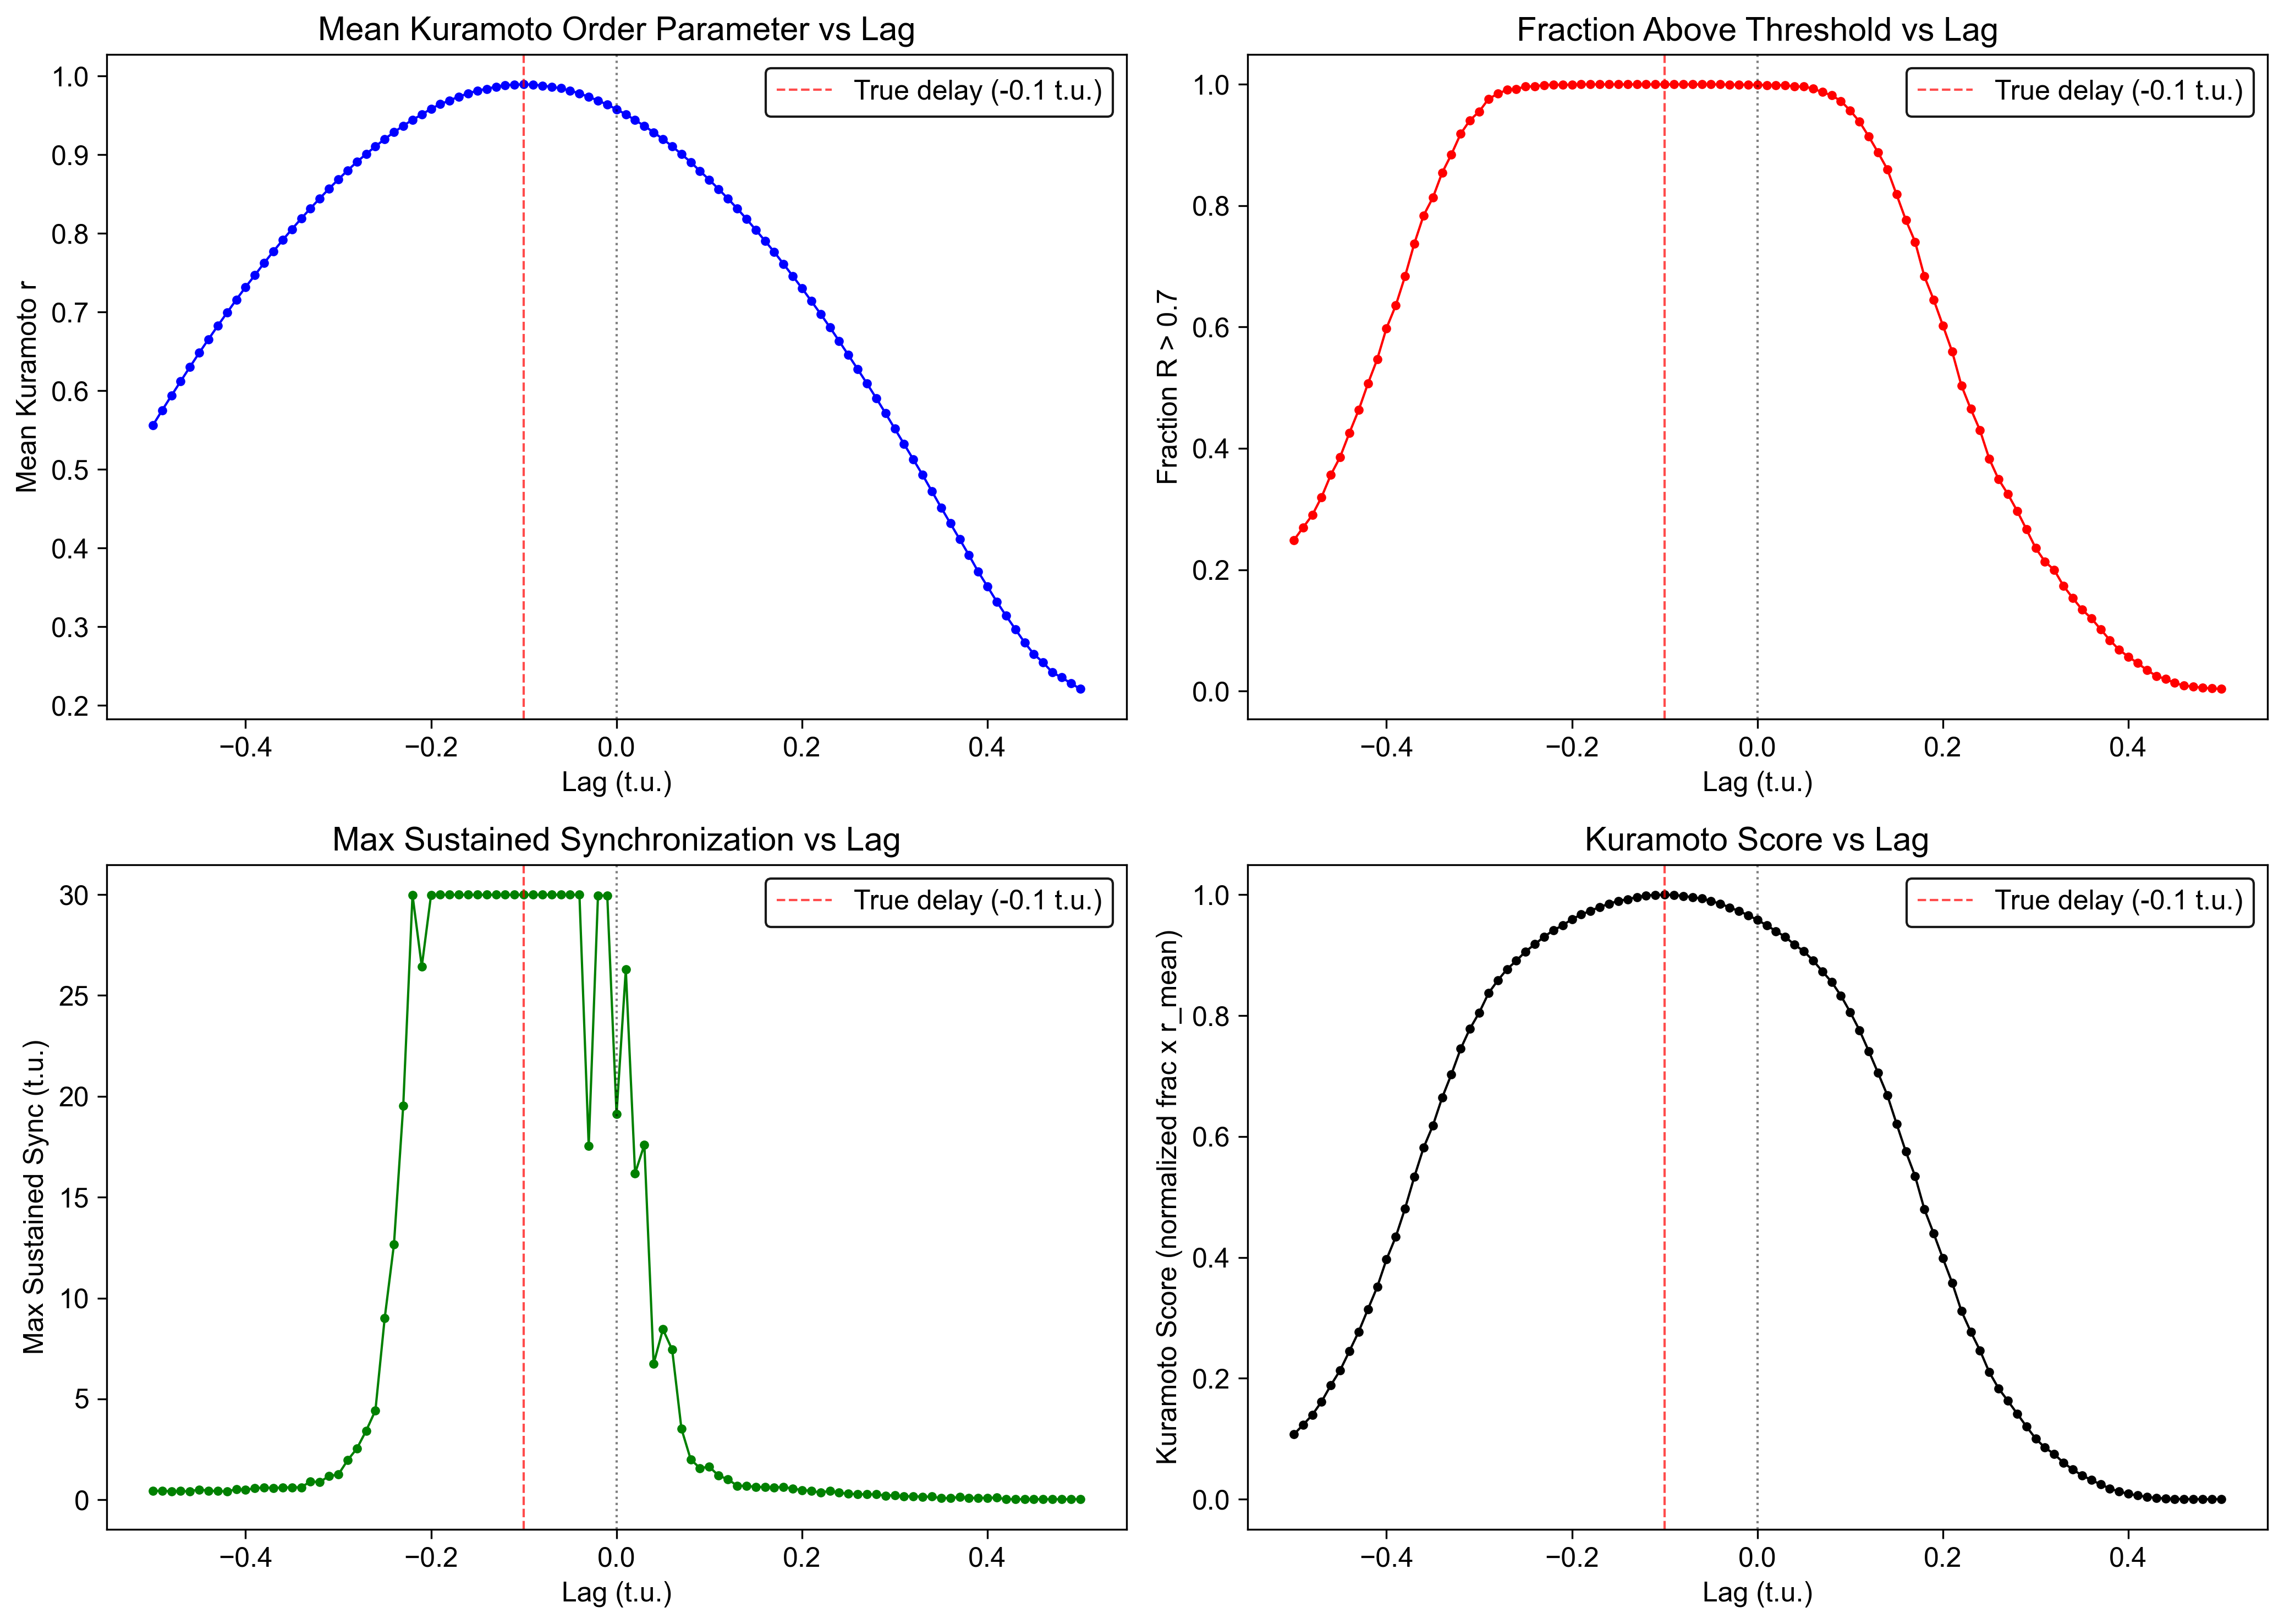

In [6]:
# Plot Kuramoto metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0, 0].plot(results_df['lag_tu'], results_df['r_mean'], 'b-o', linewidth=1, markersize=3)
axes[0, 0].set_xlabel('Lag (t.u.)')
axes[0, 0].set_ylabel('Mean Kuramoto r')
axes[0, 0].set_title('Mean Kuramoto Order Parameter vs Lag')
axes[0, 0].grid(False)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f} t.u.)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[0, 1].plot(results_df['lag_tu'], results_df['frac_above_07'], 'r-o', linewidth=1, markersize=3)
axes[0, 1].set_xlabel('Lag (t.u.)')
axes[0, 1].set_ylabel('Fraction R > 0.7')
axes[0, 1].set_title('Fraction Above Threshold vs Lag')
axes[0, 1].grid(False)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f} t.u.)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[1, 0].plot(results_df['lag_tu'], results_df['max_sustained_tu'], 'g-o', linewidth=1, markersize=3)
axes[1, 0].set_xlabel('Lag (t.u.)')
axes[1, 0].set_ylabel('Max Sustained Sync (t.u.)')
axes[1, 0].set_title('Max Sustained Synchronization vs Lag')
axes[1, 0].grid(False)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f} t.u.)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[1, 1].plot(results_df['lag_tu'], results_df['kuramoto_score'], 'k-o', linewidth=1, markersize=3)
axes[1, 1].set_xlabel('Lag (t.u.)')
axes[1, 1].set_ylabel('Kuramoto Score (normalized frac x r_mean)')
axes[1, 1].set_title('Kuramoto Score vs Lag')
axes[1, 1].grid(False)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f} t.u.)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

## Plot JRP Metrics vs Lag

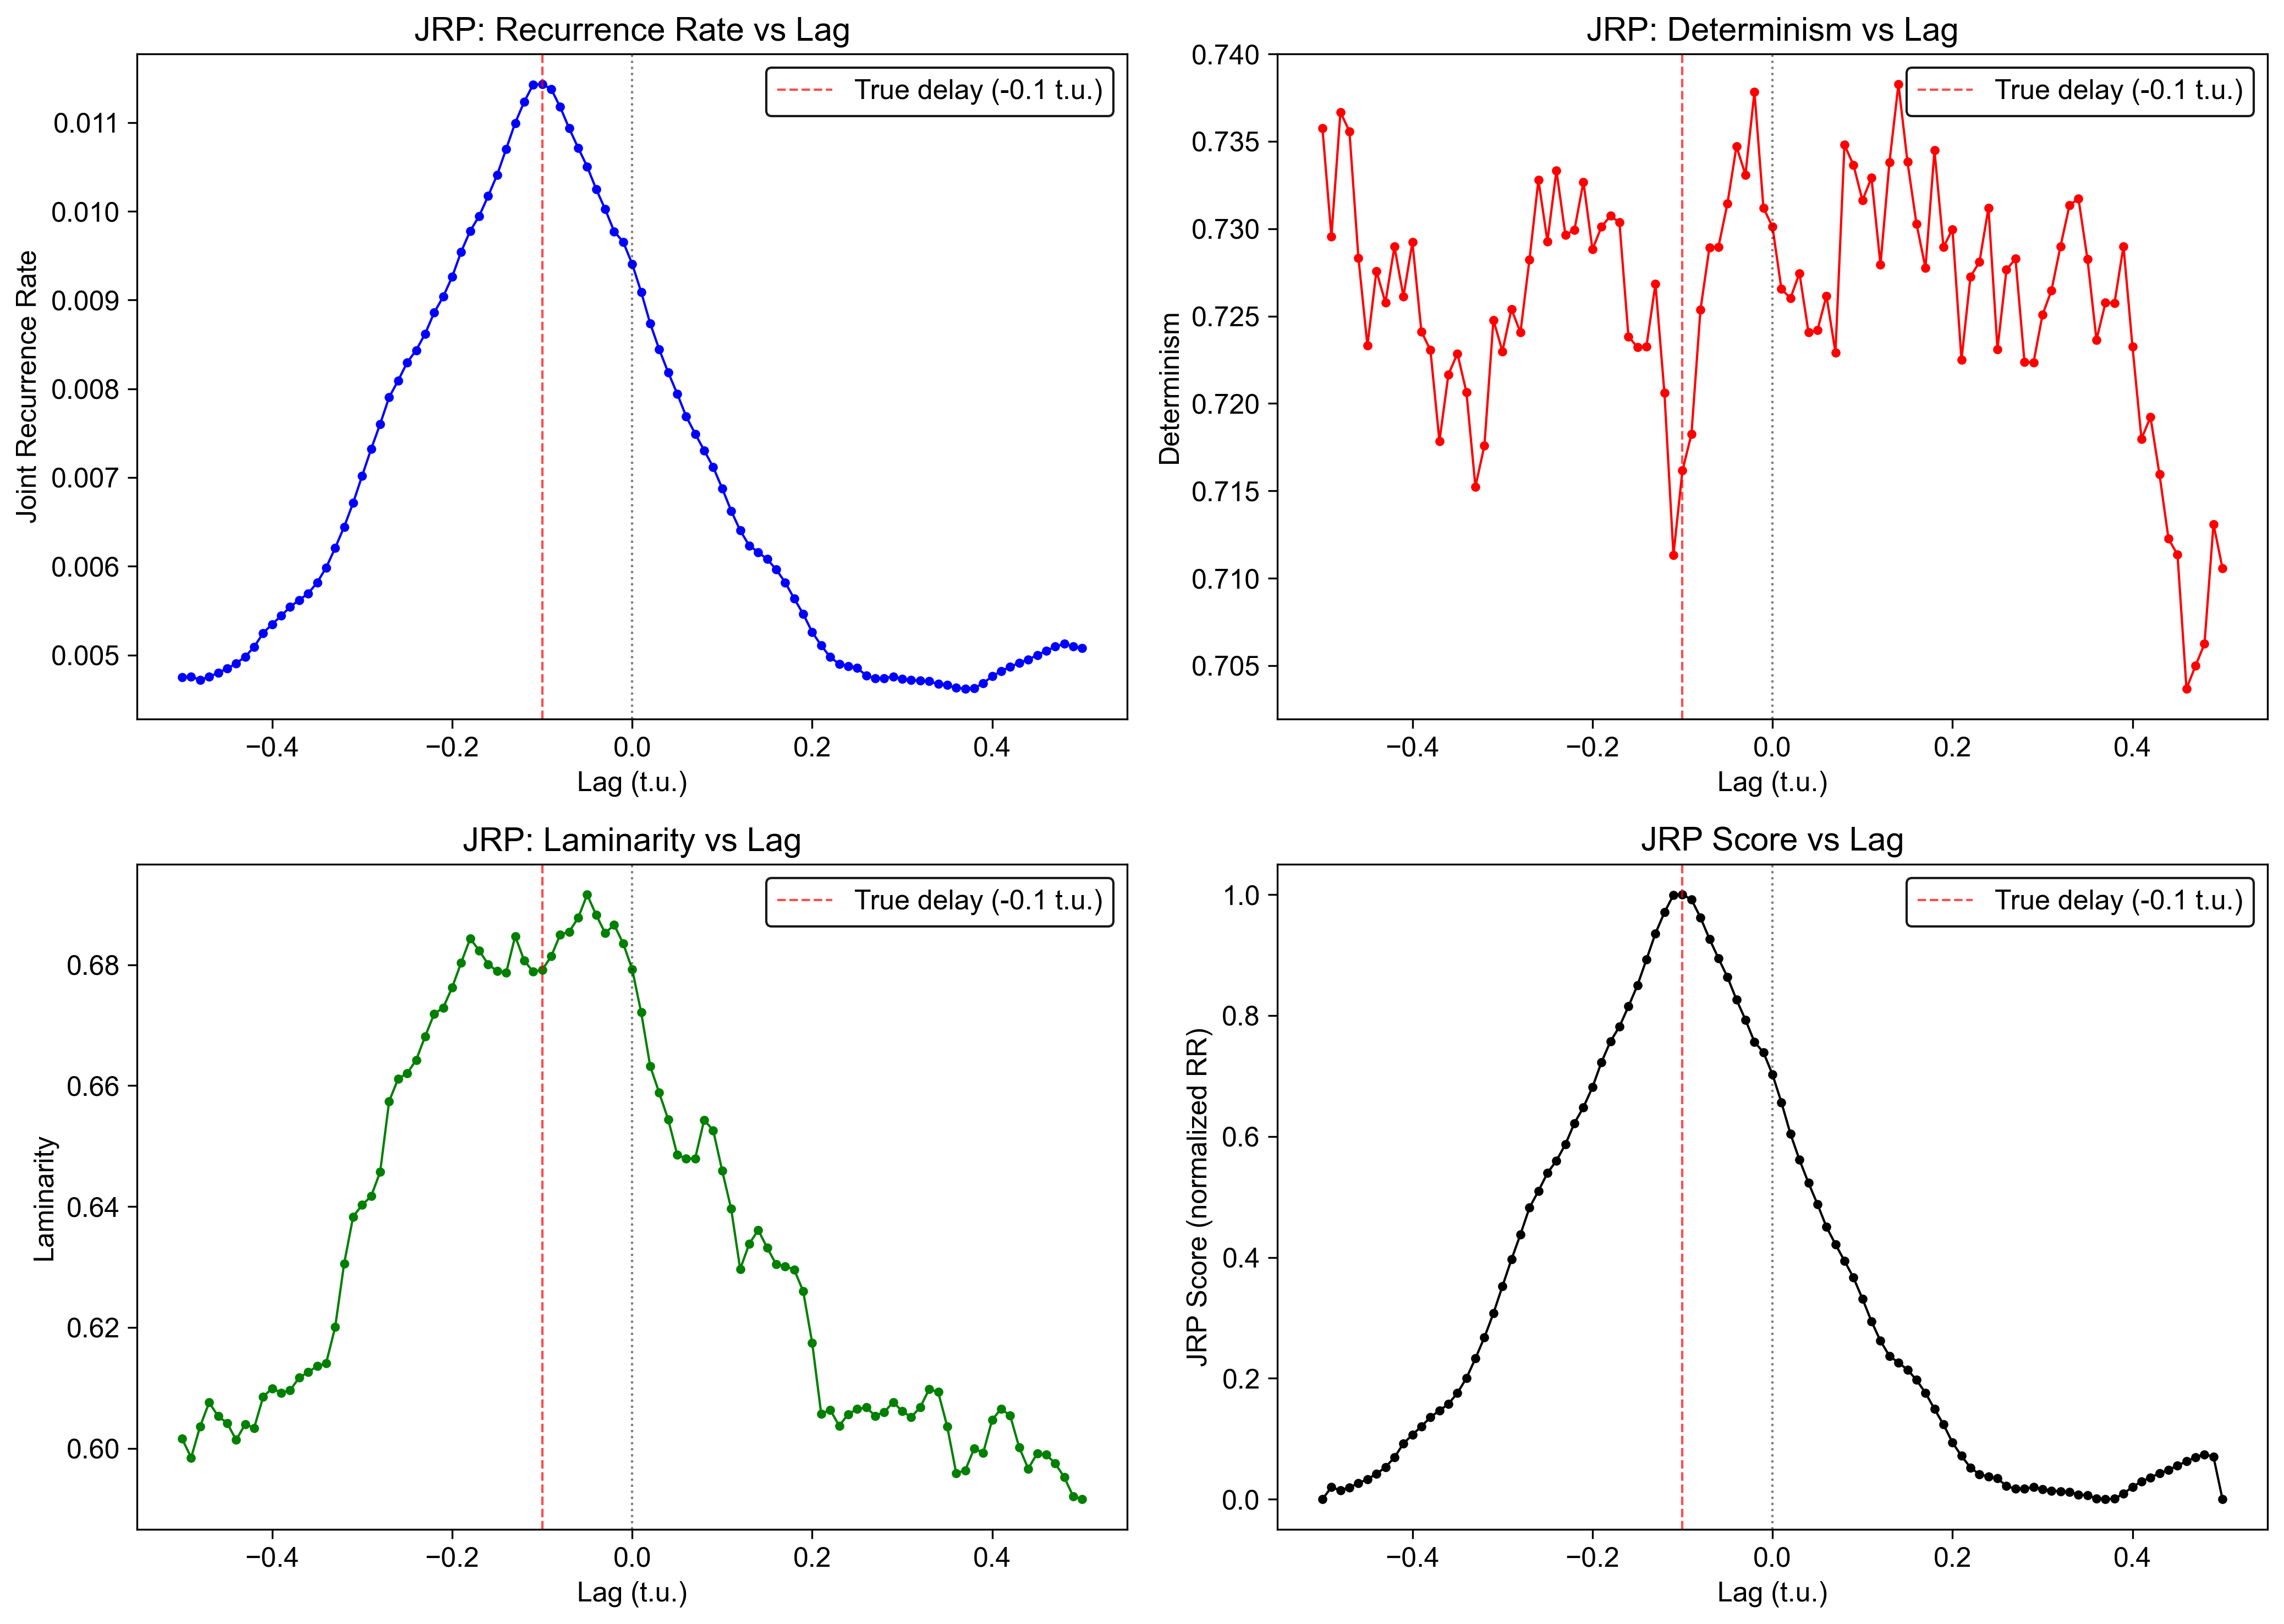

In [7]:
# Plot JRP metrics
jrp_df = results_df[results_df['jrp_RR'] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0, 0].plot(jrp_df['lag_tu'], jrp_df['jrp_RR'], 'b-o', linewidth=1, markersize=3)
axes[0, 0].set_xlabel('Lag (t.u.)')
axes[0, 0].set_ylabel('Joint Recurrence Rate')
axes[0, 0].set_title('JRP: Recurrence Rate vs Lag')
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f} t.u.)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[0, 1].plot(jrp_df['lag_tu'], jrp_df['jrp_DET'], 'r-o', linewidth=1, markersize=3)
axes[0, 1].set_xlabel('Lag (t.u.)')
axes[0, 1].set_ylabel('Determinism')
axes[0, 1].set_title('JRP: Determinism vs Lag')
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f} t.u.)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[1, 0].plot(jrp_df['lag_tu'], jrp_df['jrp_LAM'], 'g-o', linewidth=1, markersize=3)
axes[1, 0].set_xlabel('Lag (t.u.)')
axes[1, 0].set_ylabel('Laminarity')
axes[1, 0].set_title('JRP: Laminarity vs Lag')
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f} t.u.)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[1, 1].plot(jrp_df['lag_tu'], jrp_df['jrp_score'], 'k-o', linewidth=1, markersize=3)
axes[1, 1].set_xlabel('Lag (t.u.)')
axes[1, 1].set_ylabel('JRP Score (normalized RR)')
axes[1, 1].set_title('JRP Score vs Lag')
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f} t.u.)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

## Combined Scores Plot

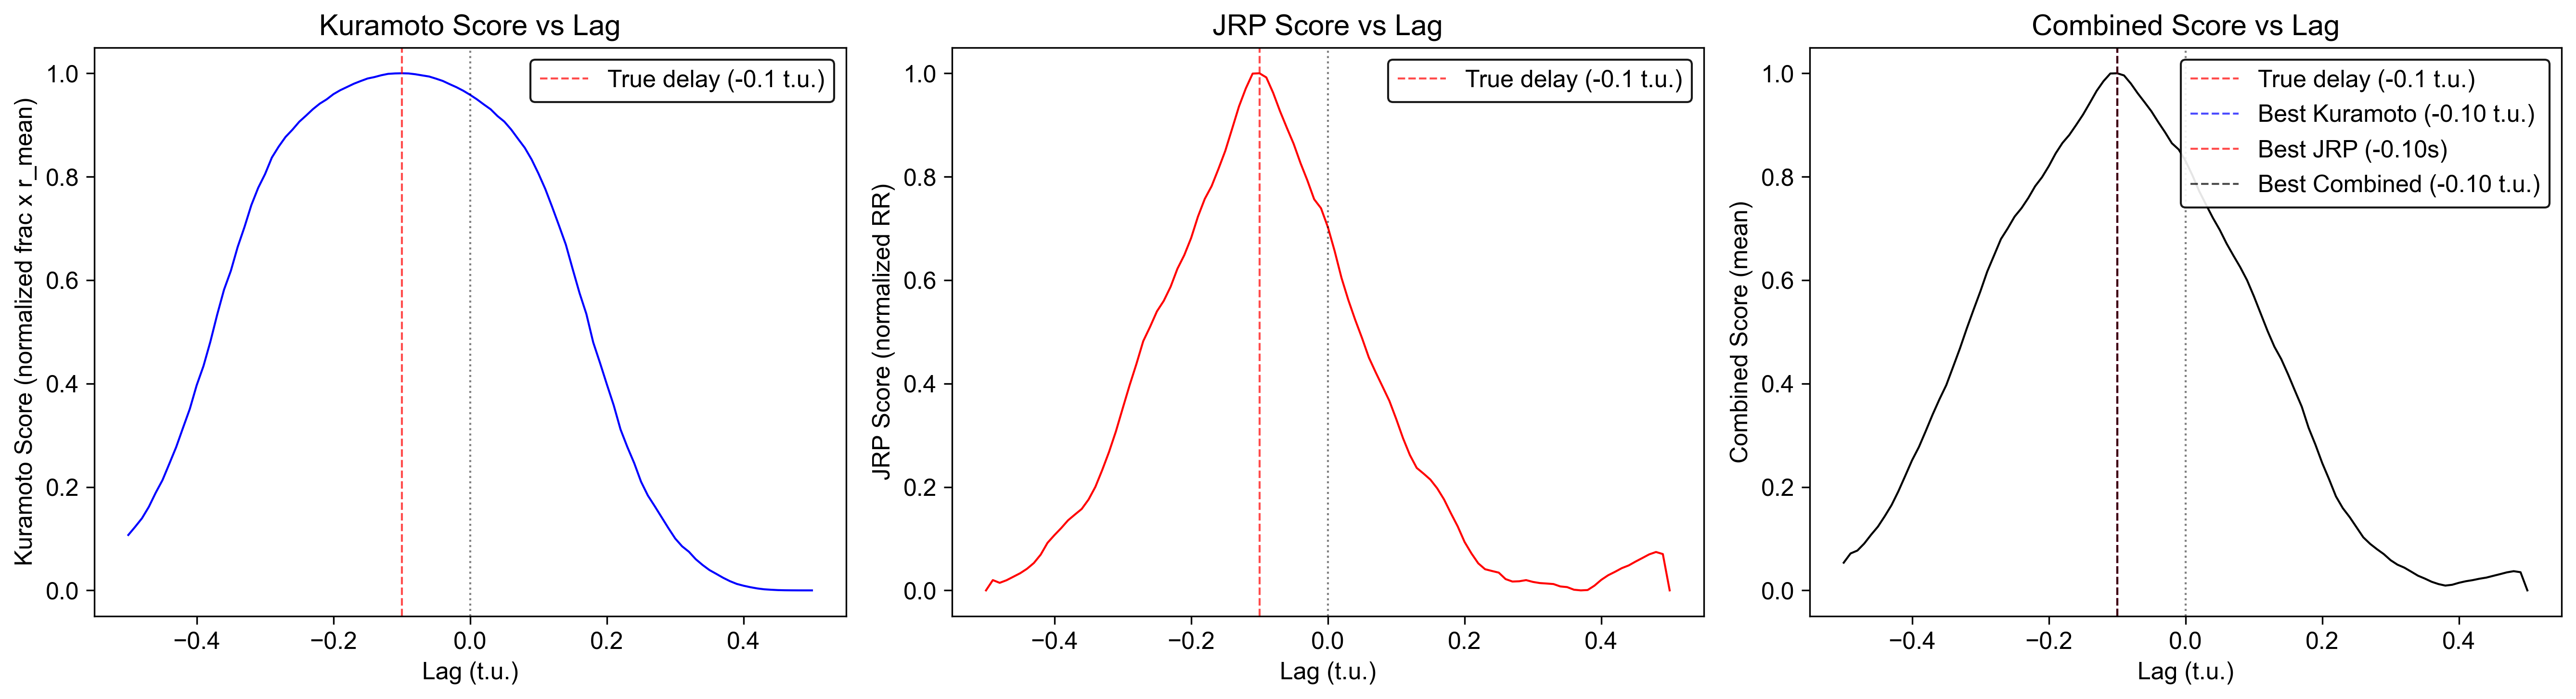

In [8]:
# Combined scores plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

axes[0].plot(results_df['lag_tu'], results_df['kuramoto_score'], 'b-', linewidth=1)
axes[0].set_xlabel('Lag (t.u.)')
axes[0].set_ylabel('Kuramoto Score (normalized frac x r_mean)')
axes[0].set_title('Kuramoto Score vs Lag')
axes[0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f} t.u.)')
axes[0].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[1].plot(jrp_df['lag_tu'], jrp_df['jrp_score'], 'r-', linewidth=1)
axes[1].set_xlabel('Lag (t.u.)')
axes[1].set_ylabel('JRP Score (normalized RR)')
axes[1].set_title('JRP Score vs Lag')
axes[1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f} t.u.)')
axes[1].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[2].plot(results_df['lag_tu'], results_df['combined_score'], 'k-', linewidth=1)
axes[2].set_xlabel('Lag (t.u.)')
axes[2].set_ylabel('Combined Score (mean)')
axes[2].set_title('Combined Score vs Lag')
axes[2].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[2].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f} t.u.)')
axes[2].axvline(x=best_kuramoto/100, color='b', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/100:.2f} t.u.)')
axes[2].axvline(x=best_jrp/100, color='r', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/100:.2f}s)')
axes[2].axvline(x=best_combined/100, color='k', linestyle='--', alpha=0.7, label=f'Best Combined ({best_combined/100:.2f} t.u.)')
axes[2].legend(frameon=True, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

## Top 10 Results

In [9]:
# Top 10 results
print('=== Top 10 by Kuramoto Score (frac_above_07 x r_mean) ===')
print(results_df.nlargest(10, 'kuramoto_score')[['lag_tu', 'r_mean', 'frac_above_07', 'max_sustained_tu', 'kuramoto_score']].to_string(index=False))

print('\n=== Top 10 by JRP Score (RR only, excl. extreme lags) ===')
print(jrp_valid.nlargest(10, 'jrp_score')[['lag_tu', 'jrp_RR', 'jrp_DET', 'jrp_LAM', 'jrp_score']].to_string(index=False))

=== Top 10 by Kuramoto Score (frac_above_07 x r_mean) ===
 lag_tu   r_mean  frac_above_07  max_sustained_tu  kuramoto_score
  -0.10 0.989360       0.999667             29.99        1.000000
  -0.11 0.989129       0.999667             29.99        0.999699
  -0.09 0.989117       0.999667             29.99        0.999684
  -0.12 0.988490       0.999667             29.99        0.998867
  -0.08 0.987882       0.999667             29.99        0.998075
  -0.13 0.986419       0.999667             29.99        0.996172
  -0.07 0.986180       0.999667             29.99        0.995861
  -0.06 0.984532       0.999667             29.99        0.993715
  -0.14 0.983704       0.999667             29.99        0.992638
  -0.15 0.981585       0.999667             29.99        0.989879

=== Top 10 by JRP Score (RR only, excl. extreme lags) ===
 lag_tu   jrp_RR  jrp_DET  jrp_LAM  jrp_score
  -0.10 0.011433 0.716163 0.679153   1.000000
  -0.11 0.011429 0.711332 0.678836   0.999412
  -0.09 0.011378 0.

## Export Results

In [10]:
# Export all results
pipeline.export_results("results/bz_delayed_pipeline")

Results exported to results/bz_delayed_pipeline/
